In [1]:
import qutip as qt
from qutip import tensor, basis, qeye
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.gate_extender import Gate_extender, Convert_levels
from quantum_logical.trotterization import Trotterization
from quantum_logical.cnot_gate_creation import cnot

In [2]:
import numpy as np
import csv
import os 

folder_path = r'C:\Users\girgi\Desktop\Github\quantum_logical\src\notebooks\Repetition_erasure_experiment'
os.chdir(folder_path)

# plot one (showing on a one cycle basis for a scan over t1 the logical error probability as a function of physical error rate)
qubit = np.loadtxt('qubit_0_t1_100.csv', delimiter=',')
qutrit_3_01 = np.loadtxt('3rd_order_01_t1_100.csv', delimiter=',')
qutrit_3_001 = np.loadtxt('3rd_order_001_t1_100.csv', delimiter=',')
qutrit_3_11 = np.loadtxt('3rd_order_11_t1_100.csv', delimiter=',')
qutrit_3_011 = np.loadtxt('3rd_order_011_t1_100_fixed.csv', delimiter=',')

qutrit_3_0_monte = np.loadtxt('3rd_order_0_t1_100_monte.csv', delimiter=',')
qutrit_3_0_no_monte = np.loadtxt('3rd_order_0_t1_100.csv', delimiter=',')
qutrit_3_0_monte_30 = np.loadtxt('3rd_order_0_t1_100_monte_30.csv', delimiter=',')
qutrit_3_0_monte_100 = np.loadtxt('3rd_order_0_t1_100_monte_100.csv', delimiter=',')

qutrit_3_0_t1 = np.loadtxt('3rd_order_t1_100_phase.csv', delimiter=',')
qutrit_5_0_t1 = np.loadtxt('5th_order_t1_100_phase.csv', delimiter=',')

qutrit_3_0 = np.loadtxt('3rd_order_phase.csv', delimiter=',')
qutrit_5_0 = np.loadtxt('5th_order_phase.csv', delimiter=',')

qutrit_3_t2 = np.loadtxt('3rd_order_phase_varying_t2_.csv', delimiter=',')
qutrit_5_t2 = np.loadtxt('5th_order_phase_varying_t2_.csv', delimiter=',')

qutrit_3_01_order = np.loadtxt('qutrit3_01.csv', delimiter=',')
qutrit_3_11_order = np.loadtxt('qutrit3_11.csv', delimiter=',')
qutrit_3_001_order = np.loadtxt('qutrit3_001.csv', delimiter=',')
qutrit_3_011_order = np.loadtxt('qutrit3_011.csv', delimiter=',')
qubit_0_ = np.loadtxt('qubit_0_fixed_t1.csv', delimiter=',')
qutrit_0_order = np.loadtxt('qutrit3_0_.csv', delimiter=',')


qutrit_3_01_order_fixed = np.loadtxt('3rd_order_01_t1_fixed_diff.csv', delimiter=',')
qutrit_3_11_order_fixed = np.loadtxt('3rd_order_11_t1_fixed_diff.csv', delimiter=',')
qutrit_3_001_order_fixed = np.loadtxt('3rd_order_001_t1_fixed_diff.csv', delimiter=',')
qutrit_3_011_order_fixed = np.loadtxt('3rd_order_011_t1_fixed_diff.csv', delimiter=',')
qubit_0_fixed = np.loadtxt('qubit_0_.csv', delimiter=',')
qutrit_0_ = np.loadtxt('qutrit3_0_fixed_t1_val.csv', delimiter=',')



In [3]:
qubit_physical_error_val = []
total_time = np.linspace(1, 100, 28)
t_phase = (2 * 100 * 100)/(2 * 100 - 100)
for i in range(len(total_time)):
    qubit_physical_error_val.append(np.exp((-total_time[i]) * ((1/100) + (1/t_phase))))

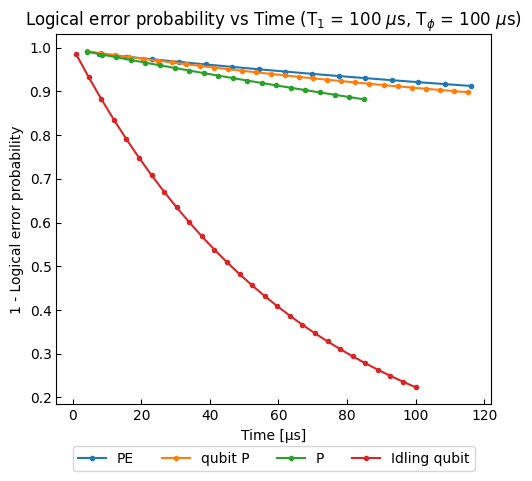

In [4]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_01_order[2][0:15], qutrit_3_01_order[1][0:15], marker=".", label="PE")
ax.plot(qubit_0_[2][0:28], qubit_0_[1][0:28], marker=".", label="qubit P")
ax.plot(qutrit_0_order[2][0:20], qutrit_0_order[1][0:20], marker=".", label="P")
ax.plot(total_time, qubit_physical_error_val, marker=".", label="Idling qubit")



plt.legend(loc="lower center", bbox_to_anchor=(.5,-.2), ncol=4)
ax.set_box_aspect(.85)
ax.tick_params(axis="both", direction="in")
# ax.set_title(r"Logical error probability vs Time (T1 = 100 \u03bcs, T\u03A6 = 66 \u03bcs)")
ax.set_title(r"Logical error probability vs Time (T$_{1}$ = 100 ${\mu}$s, T$_{\phi}$ = 100 ${\mu}$s)")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")
plt.savefig("Protocol_time.svg")


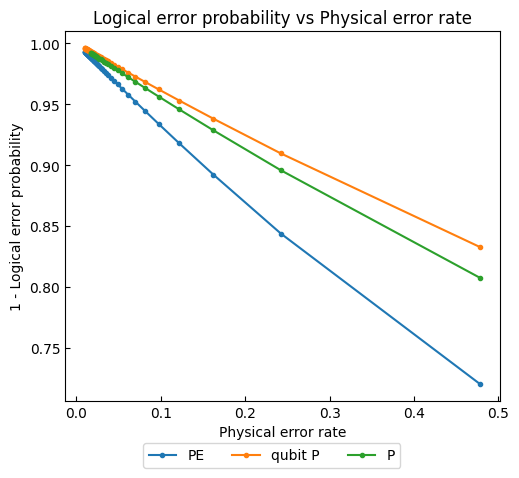

In [5]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_01_order_fixed[-1][1:50], qutrit_3_01_order_fixed[1][1:50], marker=".", label="PE")
ax.plot(qubit_0_fixed[-1][1:50], qubit_0_fixed[1][1:50], marker=".", label="qubit P")
ax.plot(qutrit_0_[-1][1:30], qutrit_0_[1][1:30], marker=".", label="P")

# fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
plt.legend(loc="lower center", bbox_to_anchor=(.475,-.2), ncol=3)
ax.tick_params(axis="both", direction="in")
ax.set_box_aspect(.85)
ax.set_title("Logical error probability vs Physical error rate")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("1 - Logical error probability")
plt.savefig("Protocol_physical.svg")

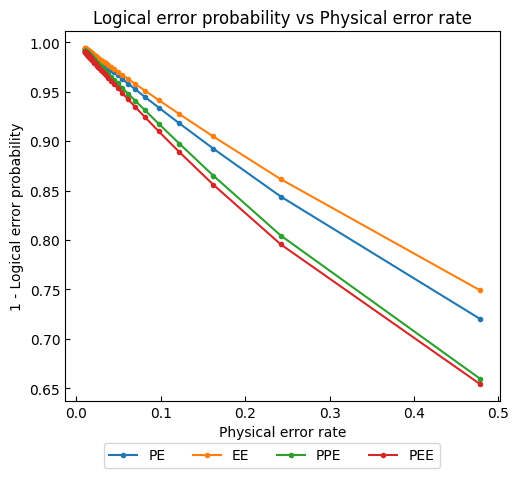

In [6]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_01_order_fixed[-1][1:50], qutrit_3_01_order_fixed[1][1:50], marker=".", label="PE")
ax.plot(qutrit_3_11_order_fixed[-1][1:50], qutrit_3_11_order_fixed[1][1:50], marker=".", label="EE")
ax.plot(qutrit_3_001_order_fixed[-1][1:50], qutrit_3_001_order_fixed[1][1:50], marker=".", label="PPE")
ax.plot(qutrit_3_011_order_fixed[-1][1:50], qutrit_3_011_order_fixed[1][1:50], marker=".", label="PEE")


plt.legend(loc="lower center", bbox_to_anchor=(.475,-.2), ncol=4)
ax.set_box_aspect(.85)
ax.set_title("Logical error probability vs Physical error rate")
ax.tick_params(axis="both", direction="in")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("1 - Logical error probability")
plt.savefig("Cadence_physical_error.svg")

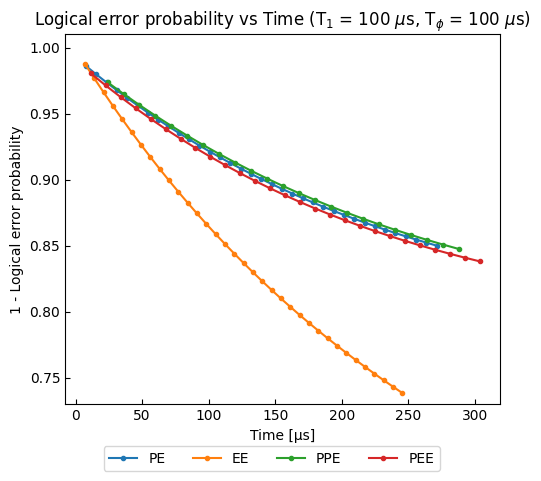

In [7]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_01_order[2], qutrit_3_01_order[1], marker=".", label="PE")
ax.plot(qutrit_3_11_order[2], qutrit_3_11_order[1], marker=".", label="EE")
ax.plot(qutrit_3_001_order[2][1:30], qutrit_3_001_order[1][1:30], marker=".", label="PPE")
ax.plot(qutrit_3_011_order[2], qutrit_3_011_order[1], marker=".", label="PEE")


# fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
plt.legend(loc="lower center", bbox_to_anchor=(.475,-.2), ncol=4)
ax.tick_params(axis="both", direction="in")
ax.set_ylim(.73, 1.01)
# plt.figure(figsize=(10, 5)) 
ax.set_box_aspect(.85)
# ax.set_title(r"Logical error probability vs Time (T1 = 100 \u03bcs, T\u03A6 = 66 \u03bcs)")
ax.set_title(r"Logical error probability vs Time (T$_{1}$ = 100 ${\mu}$s, T$_{\phi}$ = 100 ${\mu}$s)")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")
plt.savefig("Cadence.svg")

Text(0, 0.5, '1 - Logical error probability')

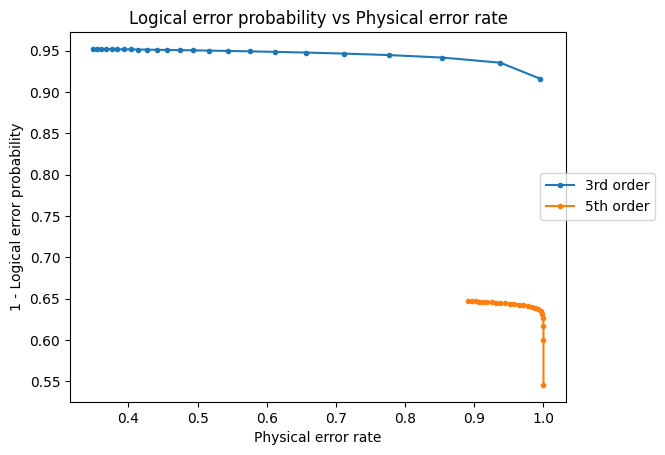

In [8]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_t2[0][1:80], qutrit_3_t2[1][1:80], marker=".", label="3rd order")
ax.plot(qutrit_5_t2[0][1:80], qutrit_5_t2[1][1:80], marker=".", label="5th order")



fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
ax.set_title("Logical error probability vs Physical error rate")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("1 - Logical error probability")
# plt.savefig("test.svg")

Text(0, 0.5, '1 - Logical error probability')

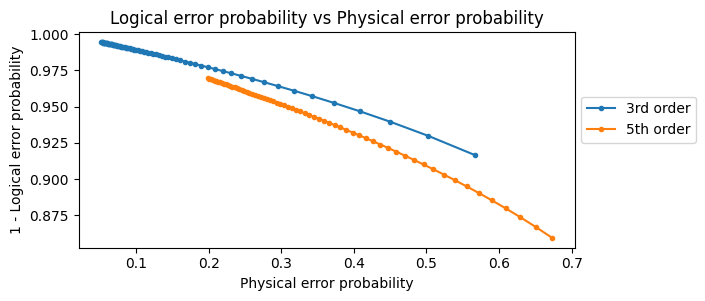

In [9]:

fig, ax = plt.subplots()
ax.set_aspect(2)
ax.plot(qutrit_3_0[0][5:80], qutrit_3_0[1][5:80], marker=".", label="3rd order")
ax.plot(qutrit_5_0[0][15:80], qutrit_5_0[1][15:80], marker=".", label="5th order")

fig.legend(loc="upper right", bbox_to_anchor=(1.1,.6))
ax.set_title("Logical error probability vs Physical error probability")
ax.set_xlabel("Physical error probability")
ax.set_ylabel("1 - Logical error probability")

Text(0, 0.5, '1 - Logical error probability')

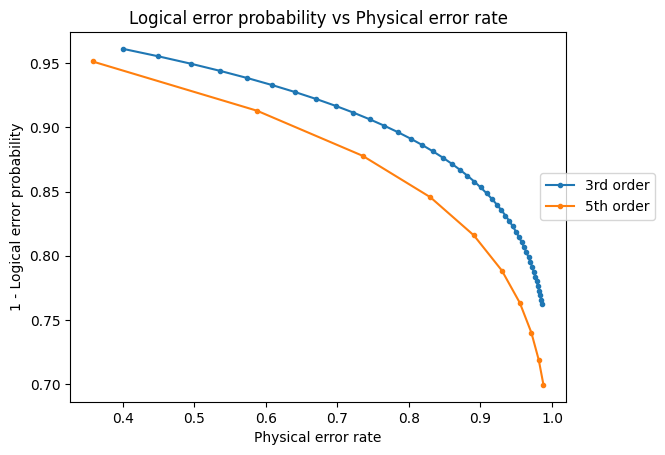

In [10]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_0_t1[0][5:50], qutrit_3_0_t1[1][5:50], marker=".", label="3rd order")
ax.plot(qutrit_5_0_t1[0][0:10], qutrit_5_0_t1[1][0:10], marker=".", label="5th order")

fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
ax.set_title("Logical error probability vs Physical error rate")
ax.set_xlabel("Physical error rate")
ax.set_ylabel("1 - Logical error probability")

Text(0, 0.5, '1 - Logical error probability')

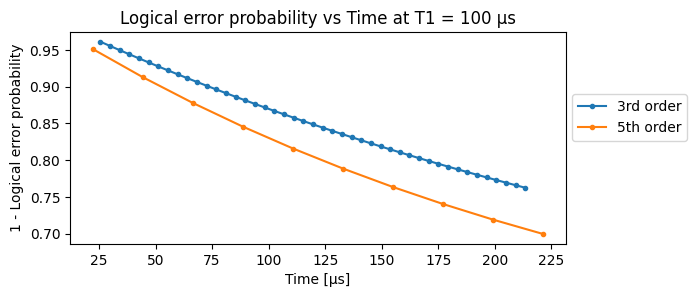

In [11]:
fig, ax = plt.subplots()
ax.set_aspect(325)
ax.plot(qutrit_3_0_t1[2][5:50], qutrit_3_0_t1[1][5:50], marker=".", label="3rd order")
ax.plot(qutrit_5_0_t1[2][0:10], qutrit_5_0_t1[1][0:10], marker=".", label="5th order")

fig.legend(loc="upper right", bbox_to_anchor=(1.1,.6))
ax.set_title("Logical error probability vs Time at T1 = 100 \u03bcs")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")

Text(0, 0.5, '1 - Logical error probability')

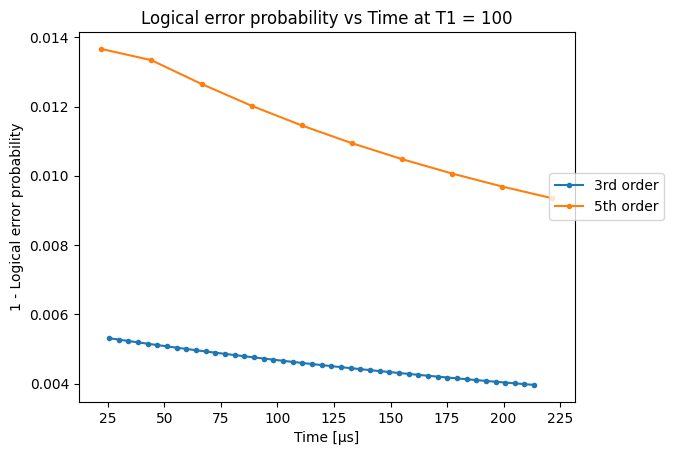

In [12]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_0_t1[2][5:50], qutrit_3_0_t1[4][5:50], marker=".", label="3rd order")
ax.plot(qutrit_5_0_t1[2][0:10], qutrit_5_0_t1[4][0:10], marker=".", label="5th order")

fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
ax.set_title("Logical error probability vs Time at T1 = 100")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")

Text(0, 0.5, '1 - Logical error probability')

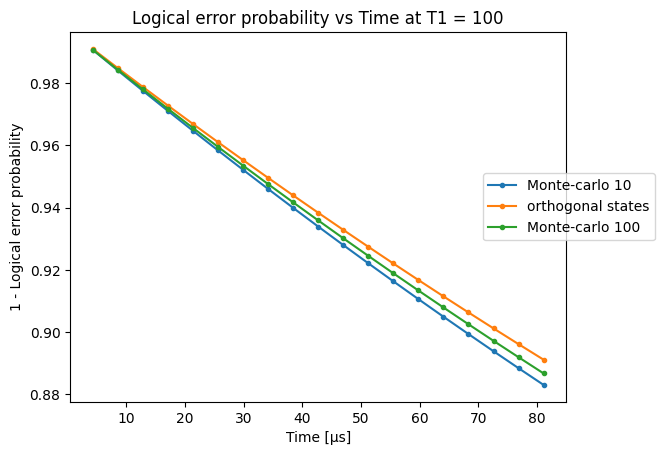

In [13]:
fig, ax = plt.subplots()
ax.plot(qutrit_3_0_monte[2][0:19], qutrit_3_0_monte[1][0:19], marker=".", label="Monte-carlo 10")
ax.plot(qutrit_3_0_no_monte[2][0:19], qutrit_3_0_no_monte[1][0:19], marker=".", label="orthogonal states")
# ax.plot(qutrit_3_0_monte_30[2][0:19], qutrit_3_0_monte_30[1][0:19], marker=".", label="Monte-carlo 30")
ax.plot(qutrit_3_0_monte_100[2][0:19], qutrit_3_0_monte_100[1][0:19], marker=".", label="Monte-carlo 100")






fig.legend(loc="upper right", bbox_to_anchor=(1.05,.6))
ax.set_title("Logical error probability vs Time at T1 = 100")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")

In [14]:
qubit_physical_error_val = []
total_time = np.linspace(1, 420, 80)
t_phase = (2 * 100 * 100)/(2 * 100 - 100)
for i in range(len(total_time)):
    qubit_physical_error_val.append(np.exp((-total_time[i]) * ((1/100) + (1/t_phase))))

Text(0, 0.5, '1 - Logical error probability')

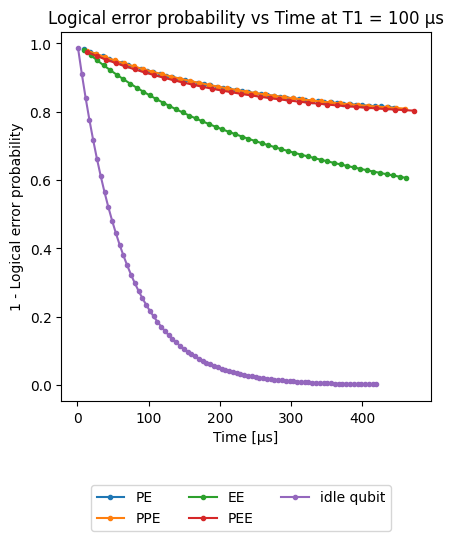

In [15]:
fig, ax = plt.subplots()
# ax.plot(qubit[2], qubit[1], marker=".", label="qubit")
ax.plot(qutrit_3_01[2], qutrit_3_01[1], marker=".", label="PE")
ax.plot(qutrit_3_001[2][0:35], qutrit_3_001[1][0:35], marker=".", label="PPE")
ax.plot(qutrit_3_11[2], qutrit_3_11[1], marker=".", label="EE")
ax.plot(qutrit_3_011[2], qutrit_3_011[1], marker=".", label="PEE")
ax.plot(total_time, qubit_physical_error_val, marker=".", label="idle qubit")

ax.set_box_aspect(1)
fig.legend(loc="upper right", bbox_to_anchor=(.75,-.05), ncol=3)
ax.set_title("Logical error probability vs Time at T1 = 100 \u03bcs")
ax.set_xlabel("Time [\u03bcs]")
ax.set_ylabel("1 - Logical error probability")